## Loading packages

In [25]:
import sys
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import os

sys.path.append("../")

warnings.filterwarnings("ignore")

# os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
# os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"

import spCLUE

spCLUE.fix_seed(0)

## Loading data

In [26]:
sample_name="151672"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [27]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())


Region
Layer3    1575
Layer6     882
Layer5     728
WM         399
Layer4     304
Name: count, dtype: int64
NA spots: 127


In [28]:
adata = spCLUE.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial")
g_expr = spCLUE.prepare_graph(adata, "expr")
graph_dict = {"spatial": g_spatia, "expr":g_expr}

normalized data ---------------->
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<


In [29]:
# # 🔥 使用新的数据准备函数
# from torch import svd
# from spCLUE.preprocess import prepare_data_for_spclue
# from sklearn.decomposition import TruncatedSVD

# adata = prepare_data_for_spclue(adata,n_hvgs=3000)
# # adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# # sc.tl.pca(adata, n_comps=200, random_state=0)
# g_spatia = spCLUE.prepare_graph(adata, "spatial")
# g_expr = spCLUE.prepare_graph(adata, "expr")
# graph_dict = {"spatial_graph": g_spatia, "expr_graph":g_expr}

## train spCLUE

In [30]:
spCLUE_model = spCLUE.spCLUE(adata.obsm["X_pca"], graph_dict, n_clusters)
_, adata.obsm["spCLUE"] = spCLUE_model.train()

ℹ️ 初始化单切片模型 (CCGCN)
Training Start =========================>


  0%|          | 0/500 [00:00<?, ?it/s]

 20%|█▉        | 99/500 [00:01<00:06, 61.34it/s]

epoch 100: 0.5828325667397682


In [31]:
# # 🔥 使用改进的spCLUE
# spCLUE_model = spCLUE.spCLUE(
#     input_data=adata.obsm['X_pca'],  # 用于编码
#     hvg_data=adata.obsm['X_hvg'],    # 🔥 用于重构
#     graph_dict=graph_dict,
#     n_clusters=n_clusters,
#     batch_list=None,                      # 🔥 单切片传None
#     batch_train=False,                    # 🔥 不用batch训练
#     use_conditional_prompt=False,         # 🔥 单切片不需要
#     recon_loss_type='sce',  # 🔥 使用SCE Loss
#     patience=20,             # 🔥 早停patience
#     epochs=500,
#     learning_rate=0.001,
#     weight_decay=0.001,
#     kappa=0.1,
#     beta=1.0,
#     gamma=0.5,  # 🔥 可能需要降低（因为HVG重构loss更大）
#     device='cuda'
# )

In [32]:
print(adata.obsm["spCLUE"].shape)


(4015, 24)


In [33]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

In [34]:
print(adata.obs.columns)


Index(['in_tissue', 'array_row', 'array_col', 'Region', 'n_counts', 'mclust',
       'mclust_refined'],
      dtype='object')


In [35]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151672: 0.7746047368459213


## visualization

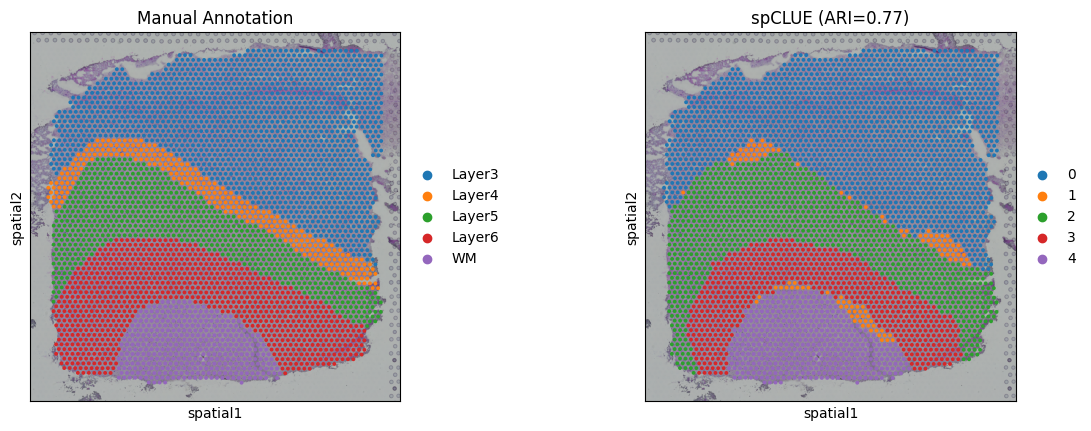

In [36]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])